# Unsupervised Learning: K-Means and DBSCAN on Iris Data

## Introduction
This notebook explores unsupervised learning by grouping data points without using labels during training. The project compares centroid-based clustering with density-based clustering and emphasizes why clustering evaluation is inherently less direct than supervised learning.

## Project Goal
Cluster Iris observations, visualize the results, compare two clustering algorithms, and test whether a smaller feature subset changes the apparent structure.

## Machine Learning Concepts Used
- Unsupervised Learning
- K-Means
- DBSCAN
- Feature Scaling
- Silhouette Score
- PCA for Visualization
- Heuristic Feature Selection

## Dataset
`sklearn.datasets.load_iris`

## Step 1: Import libraries

**What this section is doing**  
Import clustering, scaling, evaluation, and visualization tools. These are the core ingredients of a basic unsupervised learning workflow.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Step 2: Load the feature matrix

**What this section is doing**  
Load only the input features. In clustering, labels are not used during fitting.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [2]:
data = load_iris(as_frame=True)
X = data.data.copy()

print("Feature shape:", X.shape)
display(X.head())

Feature shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Step 3: Scale the features

**What this section is doing**  
Distance-based clustering methods are sensitive to variable scale, so standardization is a core preprocessing step.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 4: Project to two dimensions for plotting

**What this section is doing**  
PCA is used here for visualization only. It helps make cluster geometry visible in a 2D plot.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

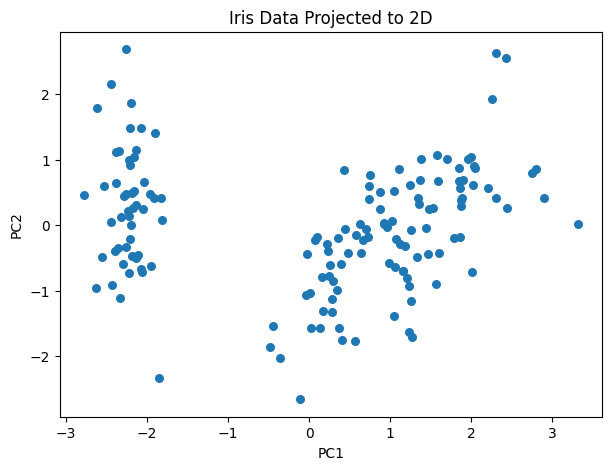

In [4]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=30)
plt.title("Iris Data Projected to 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Step 5: Run K-Means clustering

**What this section is doing**  
K-Means partitions the data by assigning each point to the nearest centroid. It works best when clusters are fairly compact and roughly spherical.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [5]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print("K-Means silhouette score:", round(kmeans_sil, 4))

K-Means silhouette score: 0.4599


## Step 6: Visualize the K-Means result

**What this section is doing**  
Plotting the cluster assignments shows how the centroid-based partition behaves in a reduced 2D space.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

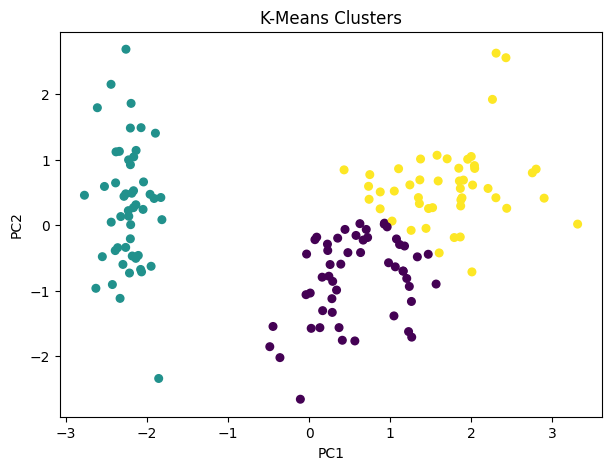

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, s=30)
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Step 7: Run DBSCAN clustering

**What this section is doing**  
DBSCAN groups points by density rather than by centroid location. It can also mark points as noise.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [7]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

label_counts = pd.Series(dbscan_labels).value_counts().sort_index().to_frame("count")
display(label_counts)

,count
-1,4
0,49
1,97


## Step 8: Visualize the DBSCAN result

**What this section is doing**  
Compare the density-based grouping to the K-Means grouping in the same 2D projection.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

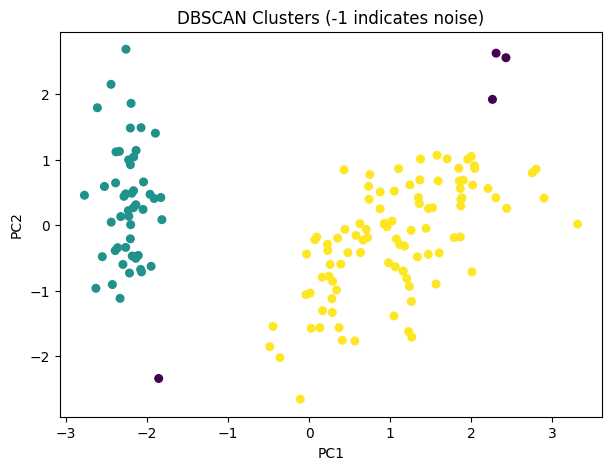

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=dbscan_labels, s=30)
plt.title("DBSCAN Clusters (-1 indicates noise)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Step 9: Refine clustering with a smaller feature subset

**What this section is doing**  
Because feature selection in unsupervised learning is more heuristic, here we try a smaller subset chosen by feature variance and see how the silhouette score changes.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [9]:
feature_variance = X.var().sort_values(ascending=False)
selected_features = feature_variance.head(2).index.tolist()
print("Selected features:", selected_features)

X_small = X[selected_features]
X_small_scaled = StandardScaler().fit_transform(X_small)

kmeans_small = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_small_labels = kmeans_small.fit_predict(X_small_scaled)

print("Selected-feature K-Means silhouette score:", round(silhouette_score(X_small_scaled, kmeans_small_labels), 4))

Selected features: ['petal length (cm)', 'sepal length (cm)']
Selected-feature K-Means silhouette score: 0.5445


## Step 10: Final analysis and next steps

**What this section is doing**  
Summarize what looked plausible, what remained uncertain, and why clustering is harder to validate than supervised learning.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

## Final Analysis

### Points for Discussion:

*   **Why feature scaling was essential:** Distance-based clustering algorithms like K-Means and DBSCAN are highly sensitive to the scale of features. Features with larger ranges or higher magnitudes can disproportionately influence the distance calculations, leading to biased clustering results. Standardizing the features (mean = 0, variance = 1) ensures that all features contribute equally to the distance metrics, allowing the algorithms to identify true clusters based on the underlying data structure rather than feature scales.

*   **How K-Means and DBSCAN differ conceptually:**
    *   **K-Means:** This is a centroid-based algorithm that partitions data into `k` predefined clusters. It assigns each data point to the cluster whose centroid is nearest, and then recomputes centroids as the mean of all points assigned to that cluster. It assumes clusters are spherical and equally sized and requires the number of clusters (`k`) to be specified beforehand.
    *   **DBSCAN:** This is a density-based algorithm that groups together data points that are closely packed together, marking as outliers points that lie alone in low-density regions. It defines clusters as areas of high density separated by areas of low density. DBSCAN does not require the number of clusters to be specified and can discover arbitrarily shaped clusters, as well as identify noise points.

*   **What silhouette score tells you and what it does not:**
    *   **What it tells you:** The silhouette score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A high silhouette value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. Scores range from -1 to 1, where:
        *   1: Indicates that the object is far away from the neighboring clusters.
        *   0: Indicates that the object is on or very close to the decision boundary between two neighboring clusters.
        *   -1: Indicates that the object is assigned to the wrong cluster.
    *   **What it does not tell you:** The silhouette score is a measure of cluster compactness and separation, but it doesn't necessarily reflect the 'correctness' of the clusters in terms of domain knowledge. It also works best for spherical clusters and might not be optimal for evaluating arbitrarily shaped clusters found by algorithms like DBSCAN.

*   **Whether the smaller feature subset helped or hurt the clustering quality:** In this case, reducing the feature set to `['petal length (cm)', 'sepal length (cm)']` resulted in a higher K-Means silhouette score (0.5445) compared to using all features (0.4599). This suggests that for K-Means, these two features provided a clearer separation or more compact clusters. This illustrates how heuristic feature selection can sometimes improve clustering quality by reducing noise or focusing on the most discriminative features.

### Next Steps:

*   **Tune K-Means and DBSCAN parameters:** Experiment with different `n_clusters` for K-Means and `eps`/`min_samples` for DBSCAN to find optimal configurations.
*   **Compare with hierarchical clustering:** Explore other clustering algorithms, such as Agglomerative or Divisive Hierarchical Clustering, to see if they yield different insights.
*   **Validate clusters against external domain knowledge when available:** The ultimate validation for unsupervised learning often comes from subject matter experts who can interpret the meaning of the discovered clusters.